In [1]:
from datetime import datetime

from uuid import uuid4

import numpy as np
from dateutil import tz

from pynwb import NWBHDF5IO, NWBFile, TimeSeries
from pynwb.behavior import Position, SpatialSeries
from pynwb.epoch import TimeIntervals
from pynwb.file import Subject

# Image Display
from IPython.display import Image

# [Tutorials](https://pynwb.readthedocs.io/en/stable/tutorials/index.html)

## General

### [NWB File Basics](https://pynwb.readthedocs.io/en/stable/tutorials/general/file.html#sphx-glr-tutorials-general-file-py)

#### NWB File, Write, Read

##### The NWB file

In [2]:
session_start_time = datetime(2018, 4, 25, 2, 30, 3, tzinfo=tz.gettz("US/Pacific"))

nwbfile = NWBFile(
    session_description="Mouse exploring an open field",  # required
    identifier=str(uuid4()),  # required
    session_start_time=session_start_time,  # required
    session_id="session_1234",  # optional
    experimenter=[
        "Baggins, Bilbo",
    ],  # optional
    lab="Bag End Laboratory",  # optional
    institution="University of My Institution",  # optional
    experiment_description="I went on an adventure to reclaim vast treasures.",  # optional
    related_publications="DOI:10.1016/j.neuron.2016.12.011",  # optional
)
print(nwbfile)

root pynwb.file.NWBFile at 0x1973923572128
Fields:
  experiment_description: I went on an adventure to reclaim vast treasures.
  experimenter: ['Baggins, Bilbo']
  file_create_date: [datetime.datetime(2023, 6, 6, 12, 47, 25, 199004, tzinfo=tzlocal())]
  identifier: d124b7a2-00d4-4142-a3e7-c08225f490d7
  institution: University of My Institution
  lab: Bag End Laboratory
  related_publications: ['DOI:10.1016/j.neuron.2016.12.011']
  session_description: Mouse exploring an open field
  session_id: session_1234
  session_start_time: 2018-04-25 02:30:03-07:00
  timestamps_reference_time: 2018-04-25 02:30:03-07:00



#### Creating/Working with Subject Data

##### Subject Information

In [3]:
Image(url= "https://pynwb.readthedocs.io/en/stable/_images/Subject.svg", width=150)

In [4]:
nwbfile.subject = Subject(
    subject_id="001",
    age="P90D",
    description="mouse 5",
    species="Mus musculus",
    sex="M",
)
print(nwbfile.subject)

subject pynwb.file.Subject at 0x1975550675744
Fields:
  age: P90D
  age__reference: birth
  description: mouse 5
  sex: M
  species: Mus musculus
  subject_id: 001



##### Time Series Data


In [5]:
Image(url= "https://pynwb.readthedocs.io/en/stable/_images/TimeSeries.png", width=200)

In [6]:
data = list(range(100, 200, 10))
time_series_with_rate = TimeSeries(
    name="test_timeseries",
    data=data,
    unit="m",
    starting_time=0.0,
    rate=1.0,
)
print(time_series_with_rate)

test_timeseries pynwb.base.TimeSeries at 0x1973926952864
Fields:
  comments: no comments
  conversion: 1.0
  data: [100 110 120 130 140 150 160 170 180 190]
  description: no description
  offset: 0.0
  rate: 1.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: m



In [7]:
timestamps = list(range(10))
time_series_with_timestamps = TimeSeries(
    name="test_timeseries",
    data=data,
    unit="m",
    timestamps=timestamps,
)
print(time_series_with_timestamps)

test_timeseries pynwb.base.TimeSeries at 0x1973926952240
Fields:
  comments: no comments
  conversion: 1.0
  data: [100 110 120 130 140 150 160 170 180 190]
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: [0 1 2 3 4 5 6 7 8 9]
  timestamps_unit: seconds
  unit: m



In [8]:
nwbfile.add_acquisition(time_series_with_timestamps)
print(nwbfile)

root pynwb.file.NWBFile at 0x1973923572128
Fields:
  acquisition: {
    test_timeseries <class 'pynwb.base.TimeSeries'>
  }
  experiment_description: I went on an adventure to reclaim vast treasures.
  experimenter: ['Baggins, Bilbo']
  file_create_date: [datetime.datetime(2023, 6, 6, 12, 47, 25, 199004, tzinfo=tzlocal())]
  identifier: d124b7a2-00d4-4142-a3e7-c08225f490d7
  institution: University of My Institution
  lab: Bag End Laboratory
  related_publications: ['DOI:10.1016/j.neuron.2016.12.011']
  session_description: Mouse exploring an open field
  session_id: session_1234
  session_start_time: 2018-04-25 02:30:03-07:00
  subject: subject pynwb.file.Subject at 0x1975550675744
Fields:
  age: P90D
  age__reference: birth
  description: mouse 5
  sex: M
  species: Mus musculus
  subject_id: 001

  timestamps_reference_time: 2018-04-25 02:30:03-07:00



In [9]:
nwbfile.acquisition["test_timeseries"]
#or 
nwbfile.get_acquisition("test_timeseries")

test_timeseries pynwb.base.TimeSeries at 0x1973926952240
Fields:
  comments: no comments
  conversion: 1.0
  data: [100 110 120 130 140 150 160 170 180 190]
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: [0 1 2 3 4 5 6 7 8 9]
  timestamps_unit: seconds
  unit: m

##### Spatial Series and Position

In [10]:
Image(url= "https://pynwb.readthedocs.io/en/stable/_images/SpatialSeries.svg", width=200)

In [11]:
# create fake data with shape (50, 2)
# the first dimension should always represent time
position_data = np.array([np.linspace(0, 10, 6), np.linspace(0, 8, 6)]).T
position_timestamps = np.linspace(0, 10, 6) / 200

spatial_series_obj = SpatialSeries(
    name="SpatialSeries",
    description="(x,y) position in open field",
    data=position_data,
    timestamps=position_timestamps,
    reference_frame="(0,0) is bottom left corner",
)
print(spatial_series_obj)

SpatialSeries pynwb.behavior.SpatialSeries at 0x1973924048960
Fields:
  comments: no comments
  conversion: 1.0
  data: [[ 0.   0. ]
 [ 2.   1.6]
 [ 4.   3.2]
 [ 6.   4.8]
 [ 8.   6.4]
 [10.   8. ]]
  description: (x,y) position in open field
  interval: 1
  offset: 0.0
  reference_frame: (0,0) is bottom left corner
  resolution: -1.0
  timestamps: [0.   0.01 0.02 0.03 0.04 0.05]
  timestamps_unit: seconds
  unit: meters



In [12]:
spatial_series_obj.fields["data"]

array([[ 0. ,  0. ],
       [ 2. ,  1.6],
       [ 4. ,  3.2],
       [ 6. ,  4.8],
       [ 8. ,  6.4],
       [10. ,  8. ]])

In [13]:
Image(url= "https://pynwb.readthedocs.io/en/stable/_images/Position.svg", width=500)

In [14]:
# Create a Position object named "Position"
# name is set to "Position" by default
position_obj = Position(spatial_series=spatial_series_obj)
print(position_obj.fields)

{'spatial_series': {'SpatialSeries': SpatialSeries pynwb.behavior.SpatialSeries at 0x1973924048960
Fields:
  comments: no comments
  conversion: 1.0
  data: [[ 0.   0. ]
 [ 2.   1.6]
 [ 4.   3.2]
 [ 6.   4.8]
 [ 8.   6.4]
 [10.   8. ]]
  description: (x,y) position in open field
  interval: 1
  offset: 0.0
  reference_frame: (0,0) is bottom left corner
  resolution: -1.0
  timestamps: [0.   0.01 0.02 0.03 0.04 0.05]
  timestamps_unit: seconds
  unit: meters
}}


##### Behavior Processing Module

ProcessingModule is a **container** for data interfaces that are related to a particular processing workflow. NWB differentiates between **raw, acquired data (acquisition)**, which should **never change**, and **processed data (processing)**, which are the results of preprocessing algorithms and **could change**. Processing modules can be thought of as folders within the file for storing the related processed data.

Let’s assume that the subject’s position was computed from a video tracking algorithm, so it would be classified as processed data.

Create a processing module called "behavior" for storing behavioral data in the NWBFile and add the Position object to the processing module using the create_processing_module method:

In [15]:
behavior_module = nwbfile.create_processing_module(
    name="behavior", description="processed behavioral data"
)
behavior_module.add(position_obj)
print(nwbfile.processing["behavior"])


behavior pynwb.base.ProcessingModule at 0x1973924050592
Fields:
  data_interfaces: {
    Position <class 'pynwb.behavior.Position'>
  }
  description: processed behavioral data



In [16]:
Image(url= "https://pynwb.readthedocs.io/en/stable/_images/Behavior.svg", width=800)

#### Writing and Reading an NWB file

NWB I/O is carried out using the NWBHDF5IO class 2. This class is responsible for mapping an NWBFile object into HDF5 according to the NWB schema.

In [17]:
# write an NWBFile
io = NWBHDF5IO("basics_tutorial.nwb", mode="w")
io.write(nwbfile)
io.close()

c:\Users\mauser00\AppData\Local\miniconda3\envs\suite2p\lib\site-packages\hdmf\build\objectmapper.py:260: DtypeConversionWarning: Spec 'TimeSeries/timestamps': Value with data type int32 is being converted to data type float64 as specified.
  warnings.warn(full_warning_msg, DtypeConversionWarning)


In [18]:
# As context Manager
with NWBHDF5IO("basics_tutorial.nwb", "w") as io:
    io.write(nwbfile)

##### Reading an NWB file

Data arrays are read passively from the file. Accessing the data attribute of the TimeSeries object does not read the data values, but presents an HDF5 object that can be indexed to read data. 

It is often preferable to read only a portion of the data.

In [21]:
with NWBHDF5IO("basics_tutorial.nwb", "r") as io:
    read_nwbfile = io.read()
    print(read_nwbfile.acquisition["test_timeseries"])
    print(read_nwbfile.acquisition["test_timeseries"].data[:])
    print(read_nwbfile.acquisition["test_timeseries"].data[:2])

test_timeseries pynwb.base.TimeSeries at 0x1973931684720
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (10,), type "<i4">
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  timestamps: <HDF5 dataset "timestamps": shape (10,), type "<f8">
  timestamps_unit: seconds
  unit: m

[100 110 120 130 140 150 160 170 180 190]
[100 110]


###### Accessing data

In [22]:
with NWBHDF5IO("basics_tutorial.nwb", "r") as io:
    read_nwbfile = io.read()
    print(read_nwbfile.processing["behavior"])
    print(read_nwbfile.processing["behavior"]["Position"])
    print(read_nwbfile.processing["behavior"]["Position"]["SpatialSeries"])

behavior pynwb.base.ProcessingModule at 0x1973931769968
Fields:
  data_interfaces: {
    Position <class 'pynwb.behavior.Position'>
  }
  description: processed behavioral data

Position pynwb.behavior.Position at 0x1973921005728
Fields:
  spatial_series: {
    SpatialSeries <class 'pynwb.behavior.SpatialSeries'>
  }

SpatialSeries pynwb.behavior.SpatialSeries at 0x1973930885280
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (6, 2), type "<f8">
  description: (x,y) position in open field
  interval: 1
  offset: 0.0
  reference_frame: (0,0) is bottom left corner
  resolution: -1.0
  timestamps: <HDF5 dataset "timestamps": shape (6,), type "<f8">
  timestamps_unit: seconds
  unit: meters



##### Appending to an NWB file

In [35]:
# First, read the file and get the interface object.
io = NWBHDF5IO("basics_tutorial.nwb", mode="a")
nwbfile = io.read()
position = nwbfile.processing["behavior"].data_interfaces["Position"]

# Next, add a new SpatialSeries.
data = list(range(300, 400, 10))
timestamps = list(range(10))

new_spatial_series = SpatialSeries(
    name="SpatialSeriesAppended",
    data=data,
    timestamps=timestamps,
    reference_frame="starting_gate",
)
position.add_spatial_series(new_spatial_series)
print(position)

# Finally, write the changes back to the file and close it.
io.write(nwbfile)
io.close()

Position pynwb.behavior.Position at 0x1973937552736
Fields:
  spatial_series: {
    SpatialSeries <class 'pynwb.behavior.SpatialSeries'>,
    SpatialSeriesAppended <class 'pynwb.behavior.SpatialSeries'>
  }



c:\Users\mauser00\AppData\Local\miniconda3\envs\suite2p\lib\site-packages\hdmf\build\objectmapper.py:260: DtypeConversionWarning: Spec 'SpatialSeries/timestamps': Value with data type int32 is being converted to data type float64 as specified.
  warnings.warn(full_warning_msg, DtypeConversionWarning)


#### Reusing timestamps

To reuse a TimeSeries timestamps in a new TimeSeries, pass the existing TimeSeries as the new TimeSeries timestamps:

In [23]:
data = list(range(101, 201, 10))
reuse_ts = TimeSeries(
    name="reusing_timeseries",
    data=data,
    unit="SIunit",
    timestamps=time_series_with_timestamps,
)

#### Time Intervals

**managing annotations in time**

##### Trials

Trials are stored in **pynwb.epoch.TimeIntervals** object which is a subclass of **pynwb.core.DynamicTable**. **pynwb.core.DynamicTable** objects are used to store tabular metadata throughout NWB, including trials, electrodes and sorted units. They offer flexibility for tabular data by allowing required columns, optional columns, and custom columns which are not defined in the standard.

In [25]:
Image(url= "https://pynwb.readthedocs.io/en/stable/_images/Trials.svg", width=400)

The trials **pynwb.core.DynamicTable** can be thought of as a table with this structure:

In [26]:
Image(url= "https://pynwb.readthedocs.io/en/stable/_images/trials_example.png", width=400)

Trials can be added to the **NWBFile** using the methods **add_trial_column** and **add_trial** We can add custom, user-defined columns to the trials table to hold data and metadata specific to this experiment or session. By default, **NWBFile** only requires the **start_time** and **end_time** of the trial. Additional columns can be added using the **add_trial_column** method.

Continue adding to our *NWBFile* by creating a new column for the trials table named *'correct'*, which will be a boolean array. Once all columns have been added, trial data can be populated using add_trial.

In [28]:
nwbfile.trials

trials pynwb.epoch.TimeIntervals at 0x1973927463568
Fields:
  colnames: ['start_time' 'stop_time' 'correct']
  columns: (
    start_time <class 'hdmf.common.table.VectorData'>,
    stop_time <class 'hdmf.common.table.VectorData'>,
    correct <class 'hdmf.common.table.VectorData'>
  )
  description: experimental trials
  id: id <class 'hdmf.common.table.ElementIdentifiers'>

In [27]:
nwbfile.add_trial_column(
    name="correct",
    description="whether the trial was correct",
)
nwbfile.add_trial(start_time=1.0, stop_time=5.0, correct=True)
nwbfile.add_trial(start_time=6.0, stop_time=10.0, correct=False)
print(nwbfile.trials.to_dataframe())

    start_time  stop_time  correct
id                                
0          1.0        5.0     True
1          6.0       10.0    False


##### Epochs

Epochs can be added to an NWB file using the method add_epoch. The first and second arguments are the start time and stop times, respectively. The third argument is one or more tags for labeling the epoch, and the fourth argument is a list of all the TimeSeries that the epoch applies to.

In [32]:
nwbfile.add_epoch(
    start_time=2.0,
    stop_time=4.0,
    tags=["first", "example"],
    timeseries=[time_series_with_timestamps],
)

nwbfile.add_epoch(
    start_time=6.0,
    stop_time=8.0,
    tags=["second", "example"],
    timeseries=[time_series_with_timestamps],
)
print(nwbfile.epochs.to_dataframe())

,start_time,stop_time,tags,timeseries
id,,,,
0,2.0,4.0,"[first, example]","[(2, 2, test_timeseries pynwb.base.TimeSeries ..."
1,6.0,8.0,"[second, example]","[(6, 2, test_timeseries pynwb.base.TimeSeries ..."


##### Other time intervals

"epochs" and "trials" are the two default names for TimeIntervals objects, but you can also add your own

In [33]:
sleep_stages = TimeIntervals(
    name="sleep_stages",
    description="intervals for each sleep stage as determined by EEG",
)

sleep_stages.add_column(name="stage", description="stage of sleep")
sleep_stages.add_column(name="confidence", description="confidence in stage (0-1)")

sleep_stages.add_row(start_time=0.3, stop_time=0.5, stage=1, confidence=0.5)
sleep_stages.add_row(start_time=0.7, stop_time=0.9, stage=2, confidence=0.99)
sleep_stages.add_row(start_time=1.3, stop_time=3.0, stage=3, confidence=0.7)

nwbfile.add_time_intervals(sleep_stages)

sleep_stages pynwb.epoch.TimeIntervals at 0x1973934402288
Fields:
  colnames: ['start_time' 'stop_time' 'stage' 'confidence']
  columns: (
    start_time <class 'hdmf.common.table.VectorData'>,
    stop_time <class 'hdmf.common.table.VectorData'>,
    stage <class 'hdmf.common.table.VectorData'>,
    confidence <class 'hdmf.common.table.VectorData'>
  )
  description: intervals for each sleep stage as determined by EEG
  id: id <class 'hdmf.common.table.ElementIdentifiers'>

In [34]:
with NWBHDF5IO("basics_tutorial.nwb", "w") as io:
    io.write(nwbfile)

c:\Users\mauser00\AppData\Local\miniconda3\envs\suite2p\lib\site-packages\hdmf\build\objectmapper.py:260: DtypeConversionWarning: Spec 'TimeSeries/timestamps': Value with data type int32 is being converted to data type float64 as specified.
  warnings.warn(full_warning_msg, DtypeConversionWarning)


### [Adding/Removing Containers from an NWB File](https://pynwb.readthedocs.io/en/stable/tutorials/general/add_remove_containers.html#sphx-glr-tutorials-general-add-remove-containers-py)

add and remove containers from an existing NWB file and either write the data back to the same file or export the data to a new file.

#### Adding objects to an NWB file in read/write mode

1. open the file with an NWBHDF5IO object in read/write mode (mode='r+' or mode='a')
2. read the NWBFile
3. add container objects to the NWBFile object
4. write the modified NWBFile using the same NWBHDF5IO object

**You cannot remove objects from an NWB file using the above method.**

In [ ]:
import datetime

import numpy as np

from pynwb import NWBHDF5IO, NWBFile, TimeSeries

# first, write a test NWB file
nwbfile = NWBFile(
    session_description="demonstrate adding to an NWB file",
    identifier="NWB123",
    session_start_time=datetime.datetime.now(datetime.timezone.utc),
)

filename = "nwbfile.nwb"
with NWBHDF5IO(filename, "w") as io:
    io.write(nwbfile)

# open the NWB file in r+ mode
with NWBHDF5IO(filename, "r+") as io:
    read_nwbfile = io.read()

    # create a TimeSeries and add it to the file under the acquisition group
    data = list(range(100, 200, 10))
    timestamps = np.arange(10, dtype=float)
    test_ts = TimeSeries(
        name="test_timeseries", data=data, unit="m", timestamps=timestamps
    )
    read_nwbfile.add_acquisition(test_ts)

    # write the modified NWB file
    io.write(read_nwbfile)

# confirm the file contains the new TimeSeries in acquisition
with NWBHDF5IO(filename, "r") as io:
    read_nwbfile = io.read()
    print(read_nwbfile)

#### Exporting a written NWB file to a new file path

Use the **NWBHDF5IO.export** method to read data from an existing NWB file, modify the data, and write the modified data to a new file path. Modifications to the data can be additions or removals of objects, such as TimeSeries objects. This is especially useful if you have raw data and processed data in the same NWB file and you want to create a new NWB file with all of the contents of the original file except for the raw data for sharing with collaborators.

To remove existing containers, use the pop method on any LabelledDict object, such as NWBFile.acquisition, **NWBFile.processing**, **NWBFile.analysis**, **NWBFile.processing**, **NWBFile.scratch**, **NWBFile.devices**,** NWBFile.stimulus**, **NWBFile.stimulus_template**, **NWBFile**.**electrode_groups**, **NWBFile.imaging_planes**, **NWBFile.icephys_electrodes**, **NWBFile.ogen_sites**, **NWBFile.lab_meta_data**, and **ProcessingModule** objects.


TimeIntervals objects, such as **NWBFile.epochs**, **NWBFile.trials**, **NWBFile.invalid_times**, and custom **TimeIntervals** objects cannot be removed (popped) from **NWBFile.intervals**.

In [ ]:
# first, create a test NWB file with a TimeSeries in the acquisition group
nwbfile = NWBFile(
    session_description="demonstrate export of an NWB file",
    identifier="NWB123",
    session_start_time=datetime.datetime.now(datetime.timezone.utc),
)
data1 = list(range(100, 200, 10))
timestamps1 = np.arange(10, dtype=float)
test_ts1 = TimeSeries(
    name="test_timeseries1", data=data1, unit="m", timestamps=timestamps1
)
nwbfile.add_acquisition(test_ts1)

# then, create a processing module for processed behavioral data
nwbfile.create_processing_module(
    name="behavior", description="processed behavioral data"
)
data2 = list(range(100, 200, 10))
timestamps2 = np.arange(10, dtype=float)
test_ts2 = TimeSeries(
    name="test_timeseries2", data=data2, unit="m", timestamps=timestamps2
)
nwbfile.processing["behavior"].add(test_ts2)

# write these objects to an NWB file
filename = "nwbfile.nwb"
with NWBHDF5IO(filename, "w") as io:
    io.write(nwbfile)

# read the written file
export_filename = "exported_nwbfile.nwb"
with NWBHDF5IO(filename, mode="r") as read_io:
    read_nwbfile = read_io.read()

    # add a new TimeSeries to the behavior processing module
    data3 = list(range(100, 200, 10))
    timestamps3 = np.arange(10, dtype=float)
    test_ts3 = TimeSeries(
        name="test_timeseries3", data=data3, unit="m", timestamps=timestamps3
    )
    read_nwbfile.processing["behavior"].add(test_ts3)

    # use the pop method to remove the original TimeSeries from the acquisition group
    read_nwbfile.acquisition.pop("test_timeseries1")

    # use the pop method to remove a TimeSeries from a processing module
    read_nwbfile.processing["behavior"].data_interfaces.pop("test_timeseries2")

    # call the export method to write the modified NWBFile instance to a new file path.
    # the original file is not modified
    with NWBHDF5IO(export_filename, mode="w") as export_io:
        export_io.export(src_io=read_io, nwbfile=read_nwbfile)

# confirm the exported file does not contain TimeSeries with names 'test_timeseries1' or 'test_timeseries2'
# but does contain a new TimeSeries in processing['behavior'] with name 'test_timeseries3'
with NWBHDF5IO(export_filename, "r") as io:
    read_nwbfile = io.read()
    print(read_nwbfile)
    print(read_nwbfile.processing["behavior"])

#### Exporting with new object IDs

When exporting a read NWB file to a new file path, the object IDs within the original NWB file will be copied to the new file. To make the exported NWB file contain a new set of object IDs, call **generate_new_id** on your **NWBFile** object. This will generate a new object ID for the **NWBFile** object and all of the objects within the NWB file.

In [ ]:
export_filename = "exported_nwbfile.nwb"
with NWBHDF5IO(filename, mode="r") as read_io:
    read_nwbfile = read_io.read()
    read_nwbfile.generate_new_id()

    with NWBHDF5IO(export_filename, mode="w") as export_io:
        export_io.export(src_io=read_io, nwbfile=read_nwbfile)

### [Annotating Time Intervals](https://pynwb.readthedocs.io/en/stable/tutorials/general/plot_timeintervals.html#sphx-glr-tutorials-general-plot-timeintervals-py)

### [Exploratory Data Analysis with NWB](https://pynwb.readthedocs.io/en/stable/tutorials/general/scratch.html#sphx-glr-tutorials-general-scratch-py)

his example will focus on the basics of working with an **NWBFile** to do more than storing standardized data for use and exchange. For example, you may want to store results from intermediate analyses or one-off analyses with unknown utility. This functionality is primarily accomplished with linking and scratch space.

##### Raw data

To demonstrate linking and scratch space, lets assume we are starting with some acquired data.

In [ ]:
from datetime import datetime

import numpy as np
from dateutil.tz import tzlocal

from pynwb import NWBHDF5IO, NWBFile, TimeSeries

# set up the NWBFile
start_time = datetime(2019, 4, 3, 11, tzinfo=tzlocal())
create_date = datetime(2019, 4, 15, 12, tzinfo=tzlocal())

nwb = NWBFile(
    session_description="demonstrate NWBFile scratch",  # required
    identifier="NWB456",  # required
    session_start_time=start_time,  # required
    file_create_date=create_date,
)  # optional

# make some fake data
timestamps = np.linspace(0, 100, 1024)
data = (
    np.sin(0.333 * timestamps)
    + np.cos(0.1 * timestamps)
    + np.random.randn(len(timestamps))
)
test_ts = TimeSeries(name="raw_timeseries", data=data, unit="m", timestamps=timestamps)

# add it to the NWBFile
nwb.add_acquisition(test_ts)

with NWBHDF5IO("raw_data.nwb", mode="w") as io:
    io.write(nwb)

##### Copying an NWB file

In [ ]:
# To copy a file, we must first read the file.
raw_io = NWBHDF5IO("raw_data.nwb", "r")
nwb_in = raw_io.read()
# And then create a shallow copy the file with the copy method of NWBFile .
nwb_proc = nwb_in.copy()

Now that we have a copy, lets process some data, and add the results as a ProcessingModule to our copy of the file. 

The **processed_data.nwb** file (i.e., our copy) stores our processing module and contains external links to all data in our original file, i.e., the data from our raw file is being linked to, not copied. This allows us to isolate our processing data in a separate file while still allowing us to access the raw data from our processed_data.nwb file, without having to duplicate the data.

In [ ]:
import scipy.signal as sps

mod = nwb_proc.create_processing_module(
    "filtering_module", "a module to store filtering results"
)

ts1 = nwb_in.acquisition["raw_timeseries"]
filt_data = sps.correlate(ts1.data, np.ones(128), mode="same") / 128
ts2 = TimeSeries(name="filtered_timeseries", data=filt_data, unit="m", 
                 timestamps=ts1) # reusing the timestamps

mod.add_container(ts2)

# Now write the copy, which contains the processed data.
with NWBHDF5IO("processed_data.nwb", mode="w", manager=raw_io.manager) as io:
    io.write(nwb_proc)

##### Adding scratch data

You may end up wanting to store results from some one-off analysis, and writing an extension to get your data into an NWBFile is too much over head. This is facilitated by the scratch space in NWB:N.

In [ ]:
# First, lets read our processed data and then make a copy
proc_io = NWBHDF5IO("processed_data.nwb", "r")
nwb_proc_in = proc_io.read()
# Now make a copy to put our scratch data into 4
nwb_scratch = nwb_proc_in.copy()

# fast Analysis to store for future work (not for others)
filt_ts = nwb_scratch.modules["filtering_module"]["filtered_timeseries"]

fft = np.fft.fft(filt_ts.data)

nwb_scratch.add_scratch(
    fft,
    name="dft_filtered",
    description="discrete Fourier transform from filtered data",
)

# Save scratch analysis
with NWBHDF5IO("scratch_analysis.nwb", "w", manager=proc_io.manager) as io:
    io.write(nwb_scratch)

In [ ]:
# Get results back
scratch_io = NWBHDF5IO("scratch_analysis.nwb", "r")
nwb_scratch_in = scratch_io.read()

fft_in = nwb_scratch_in.scratch["dft_filtered"]
# or
fft_in = nwb_scratch_in.get_scratch("dft_filtered")

# close the IO objects
raw_io.close()
proc_io.close()
scratch_io.close()

### [Extending NWB](https://pynwb.readthedocs.io/en/stable/tutorials/general/extensions.html#sphx-glr-tutorials-general-extensions-py)

##### Defining extensions

In [43]:
from pynwb.spec import NWBAttributeSpec, NWBGroupSpec, NWBNamespaceBuilder

ns_path = "mylab.namespace.yaml"
ext_source = "mylab.extensions.yaml"

ns_builder = NWBNamespaceBuilder(
    "Extension for use in my Lab", "mylab", version="0.1.0"
)

ns_builder.include_type("ElectricalSeries", namespace="core")

ext = NWBGroupSpec(
    "A custom ElectricalSeries for my lab",
    attributes=[NWBAttributeSpec("trode_id", "the tetrode id", "int")],
    neurodata_type_inc="ElectricalSeries",
    neurodata_type_def="TetrodeSeries",
)

ns_builder.add_spec(ext_source, ext)
ns_builder.export(ns_path)
for key, value in ext.items():
   print(f"{key}: {value}")

doc: A custom ElectricalSeries for my lab
neurodata_type_inc: ElectricalSeries
neurodata_type_def: TetrodeSeries
attributes: [{'doc': 'the tetrode id', 'name': 'trode_id', 'dtype': 'int'}]


##### Using extensions

After an extension has been created, it can be used by downstream codes for reading and writing data. There are two main mechanisms for reading and writing extension data with PyNWB. The first involves defining new **NWBContainer** classes that are then mapped to the neurodata types in the extension.

In [44]:
from hdmf.utils import docval, get_docval, popargs

from pynwb import load_namespaces, register_class
from pynwb.ecephys import ElectricalSeries

ns_path = "mylab.namespace.yaml"
load_namespaces(ns_path)


@register_class("TetrodeSeries", "mylab")
class TetrodeSeries(ElectricalSeries):
    __nwbfields__ = ("trode_id",)

    @docval(
        *get_docval(ElectricalSeries.__init__)
        + ({"name": "trode_id", "type": int, "doc": "the tetrode id"},)
    )
    def __init__(self, **kwargs):
        trode_id = popargs("trode_id", kwargs)
        super().__init__(**kwargs)
        self.trode_id = trode_id

When extending **NWBContainer** or **NWBContainer** subclasses, you should define the class field **__nwbfields__**. This will tell PyNWB the properties of the **NWBContainer** extension.

If you do not want to write additional code to read your extensions, PyNWB is able to dynamically create an **NWBContainer** subclass for use within the PyNWB API. Dynamically created classes can be inspected using the built-in **inspect** module.

In [45]:
from pynwb import get_class, load_namespaces

ns_path = "mylab.namespace.yaml"
load_namespaces(ns_path)

AutoTetrodeSeries = get_class("TetrodeSeries", "mylab")

In [50]:
AutoTetrodeSeries.get_fields_conf()

({'name': 'comments',
  'doc': 'Human-readable comments about this TimeSeries dataset'},
 {'name': 'description', 'doc': 'Description of this TimeSeries dataset'},
 {'name': 'data',
  'doc': 'The data values. The first dimension must be time. Can also store binary data, e.g., image frames'},
 {'name': 'resolution',
  'doc': 'The smallest meaningful difference (in specified unit) between values in data'},
 {'name': 'conversion',
  'doc': 'Scalar to multiply each element in data to convert it to the specified unit'},
 {'name': 'offset',
  'doc': "Scalar to add to each element in the data scaled by 'conversion' to finish converting it to the specified unit."},
 {'name': 'unit', 'doc': 'The base unit of measurement (should be SI unit)'},
 {'name': 'timestamps', 'doc': 'Timestamps for samples stored in data'},
 {'name': 'timestamps_unit', 'doc': None},
 {'name': 'interval', 'doc': None},
 {'name': 'starting_time', 'doc': 'The timestamp of the first sample'},
 {'name': 'rate', 'doc': 'Sampli

##### Caching extensions to file

By default, extensions are cached to file so that your NWB file will carry the extensions needed to read the file with it.

In [51]:
from datetime import datetime

from dateutil.tz import tzlocal

from pynwb import NWBFile

start_time = datetime(2017, 4, 3, 11, tzinfo=tzlocal())
create_date = datetime(2017, 4, 15, 12, tzinfo=tzlocal())

nwbfile = NWBFile(
    "demonstrate caching", "NWB456", start_time, file_create_date=create_date
)

device = nwbfile.create_device(name="trodes_rig123")

electrode_name = "tetrode1"
description = "an example tetrode"
location = "somewhere in the hippocampus"

electrode_group = nwbfile.create_electrode_group(
    electrode_name, description=description, location=location, device=device
)
for idx in [1, 2, 3, 4]:
    nwbfile.add_electrode(
        id=idx,
        x=1.0,
        y=2.0,
        z=3.0,
        imp=float(-idx),
        location="CA1",
        filtering="none",
        group=electrode_group,
    )
electrode_table_region = nwbfile.create_electrode_table_region(
    [0, 2], "the first and third electrodes"
)

import numpy as np

rate = 10.0
np.random.seed(1234)
data_len = 1000
data = np.random.rand(data_len * 2).reshape((data_len, 2))
timestamps = np.arange(data_len) / rate

ts = TetrodeSeries(
    "test_ephys_data",
    data,
    electrode_table_region,
    timestamps=timestamps,
    trode_id=1,
    # Alternatively, could specify starting_time and rate as follows
    # starting_time=ephys_timestamps[0],
    # rate=rate,
    resolution=0.001,
    comments="This data was randomly generated with numpy, using 1234 as the seed",
    description="Random numbers generated with numpy.random.rand",
)
nwbfile.add_acquisition(ts)

In [52]:
from pynwb import NWBHDF5IO

io = NWBHDF5IO("cache_spec_example.nwb", mode="w")
io.write(nwbfile)
io.close()

In [53]:
with NWBHDF5IO("cache_spec_example.nwb", mode="r", load_namespaces=True) as io:
    nwbfile = io.read()

In [66]:
print(nwbfile.acquisition)

{'test_ephys_data': test_ephys_data __main__.TetrodeSeries at 0x1973937567104
Fields:
  comments: This data was randomly generated with numpy, using 1234 as the seed
  conversion: 1.0
  description: Random numbers generated with numpy.random.rand
  interval: 1
  offset: 0.0
  resolution: 0.001
  timestamps_unit: seconds
  trode_id: 1
  unit: volts
}


##### Creating and using a custom MultiContainerInterface

It is sometimes the case that we need a group to hold zero-or-more or one-or-more of the same object. Here we show how to create an extension that defines a group (PotatoSack) that holds multiple objects (Potato) and then how to use the new data types. First, we use pynwb to define the new data types.

In [68]:
from pynwb.spec import NWBAttributeSpec, NWBGroupSpec, NWBNamespaceBuilder

name = "test_multicontainerinterface"
ns_path = name + ".namespace.yaml"
ext_source = name + ".extensions.yaml"

ns_builder = NWBNamespaceBuilder(name + " extensions", name, version="0.1.0")
ns_builder.include_type("NWBDataInterface", namespace="core")

potato = NWBGroupSpec(
    neurodata_type_def="Potato",
    neurodata_type_inc="NWBDataInterface",
    doc="A potato",
    quantity="*",
    attributes=[
        NWBAttributeSpec(
            name="weight", doc="weight of potato", dtype="float", required=True
        ),
        NWBAttributeSpec(
            name="age", doc="age of potato", dtype="float", required=False
        ),
    ],
)

potato_sack = NWBGroupSpec(
    neurodata_type_def="PotatoSack",
    neurodata_type_inc="NWBDataInterface",
    name="potato_sack",
    doc="A sack of potatoes",
    quantity="?",
    groups=[potato],
)

ns_builder.add_spec(ext_source, potato_sack)
ns_builder.export(ns_path)

Then create Container classes registered to the new data types (this is generally done in a different file)

In [69]:
from pynwb import load_namespaces, register_class
from pynwb.file import MultiContainerInterface, NWBContainer

load_namespaces(ns_path)


@register_class("Potato", name)
class Potato(NWBContainer):
    __nwbfields__ = ("name", "weight", "age")

    @docval(
        {"name": "name", "type": str, "doc": "who names a potato?"},
        {"name": "weight", "type": float, "doc": "weight of potato in grams"},
        {"name": "age", "type": float, "doc": "age of potato in days"},
    )
    def __init__(self, **kwargs):
        super().__init__(name=kwargs["name"])
        self.weight = kwargs["weight"]
        self.age = kwargs["age"]


@register_class("PotatoSack", name)
class PotatoSack(MultiContainerInterface):
    __clsconf__ = {
        "attr": "potatos",
        "type": Potato,
        "add": "add_potato",
        "get": "get_potato",
        "create": "create_potato",
    }

Then use the objects (again, this would often be done in a different file).



In [70]:
from datetime import datetime

from dateutil.tz import tzlocal

from pynwb import NWBHDF5IO, NWBFile

# You can add potatoes to a potato sack in different ways
potato_sack = PotatoSack(potatos=Potato(name="potato1", age=2.3, weight=3.0))
potato_sack.add_potato(Potato("potato2", 3.0, 4.0))
potato_sack.create_potato("big_potato", 10.0, 20.0)

nwbfile = NWBFile(
    "a file with metadata", "NB123A", datetime(2018, 6, 1, tzinfo=tzlocal())
)

pmod = nwbfile.create_processing_module("module_name", "desc")
pmod.add_container(potato_sack)


with NWBHDF5IO("test_multicontainerinterface.nwb", "w") as io:
    io.write(nwbfile)

This is how you read the NWB file (again, this would often be done in a different file).



In [71]:
load_namespaces(ns_path)
# from xxx import PotatoSack, Potato
with NWBHDF5IO("test_multicontainerinterface.nwb", "r") as io:
    nwb = io.read()
    print(nwb.get_processing_module()["potato_sack"].get_potato("big_potato").weight)
# note: you can call get_processing_module() with or without the module name as
# an argument. however, if there is more than one module, the name is required.
# here, there is more than one potato, so the name of the potato is required as
# an argument to get get_potato

10.0


##### Example: Cortical Surface Mesh

Here we show how to create extensions by creating a data class for a cortical surface mesh. This data type is particularly important for ECoG data, we need to know where each electrode is with respect to the gyri and sulci. Surface mesh objects contain two types of data:

1. vertices, which is an (n, 3) matrix of floats that represents points in 3D space

2. faces, which is an (m, 3) matrix of uints that represents indices of the vertices matrix. Each triplet of points defines a triangular face, and the mesh is comprised of a collection of triangular faces.

In [ ]:
from pynwb.spec import NWBDatasetSpec, NWBGroupSpec, NWBNamespaceBuilder

name = "ecog"
ns_path = name + ".namespace.yaml"
ext_source = name + ".extensions.yaml"

# Now we define the data structures. We use `NWBDataInterface` as the base type,
# which is the most primitive type you are likely to use as a base. The name of the
# class is `CorticalSurface`, and it requires two matrices, `vertices` and
# `faces`.

surface = NWBGroupSpec(
    doc="brain cortical surface",
    datasets=[
        NWBDatasetSpec(
            doc="faces for surface, indexes vertices",
            shape=(None, 3),
            name="faces",
            dtype="uint",
            dims=("face_number", "vertex_index"),
        ),
        NWBDatasetSpec(
            doc="vertices for surface, points in 3D space",
            shape=(None, 3),
            name="vertices",
            dtype="float",
            dims=("vertex_number", "xyz"),
        ),
    ],
    neurodata_type_def="CorticalSurface",
    neurodata_type_inc="NWBDataInterface",
)

# Now we set up the builder and add this object

ns_builder = NWBNamespaceBuilder(name + " extensions", name, version="0.1.0")
ns_builder.add_spec(ext_source, surface)
ns_builder.export(ns_path)

################
# The above should generate 2 YAML files. `ecog.extensions.yaml`,
# defines the newly defined types
#
# .. code-block:: yaml
#
#     # ecog.namespace.yaml
#       groups:
#       - datasets:
#       - dims:
#           - face_number
#           - vertex_index
#           doc: faces for surface, indexes vertices
#           dtype: uint
#           name: faces
#           shape:
#           - null
#           - 3
#       - dims:
#           - vertex_number
#           - xyz
#           doc: vertices for surface, points in 3D space
#           dtype: float
#           name: vertices
#           shape:
#           - null
#           - 3
#       doc: brain cortical surface
#       neurodata_type_def: CorticalSurface
#       neurodata_type_inc: NWBDataInterface
#
# Finally, we should test the new types to make sure they run as expected

from datetime import datetime

import numpy as np

from pynwb import NWBHDF5IO, NWBFile, get_class, load_namespaces

load_namespaces("ecog.namespace.yaml")
CorticalSurface = get_class("CorticalSurface", "ecog")

cortical_surface = CorticalSurface(
    vertices=[
        [0.0, 1.0, 1.0],
        [1.0, 1.0, 2.0],
        [2.0, 2.0, 1.0],
        [2.0, 1.0, 1.0],
        [1.0, 2.0, 1.0],
    ],
    faces=np.array([[0, 1, 2], [1, 2, 3]]).astype("uint"),
    name="cortex",
)

nwbfile = NWBFile("my first synthetic recording", "EXAMPLE_ID", datetime.now())

cortex_module = nwbfile.create_processing_module(
    name="cortex", description="description"
)
cortex_module.add_container(cortical_surface)


with NWBHDF5IO("test_cortical_surface.nwb", "w") as io:
    io.write(nwbfile)

### [Object IDs in NWB](https://pynwb.readthedocs.io/en/stable/tutorials/general/object_id.html#sphx-glr-tutorials-general-object-id-py)

### [Reading and Exploring an NWB File](https://pynwb.readthedocs.io/en/stable/tutorials/general/read_basics.html#sphx-glr-tutorials-general-read-basics-py)

## Domain Specific

### [Calcium Imaging Data](https://pynwb.readthedocs.io/en/stable/tutorials/domain/ophys.html#sphx-glr-tutorials-domain-ophys-py)

1. Create imaging plane
2. Add acquired two-photon images
3. Add motion correction (optional)
4. Add image segmentation
5. Add fluorescence and dF/F responses

In [2]:
from datetime import datetime
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
from dateutil.tz import tzlocal

from pynwb import NWBHDF5IO, NWBFile, TimeSeries
from pynwb.image import ImageSeries
from pynwb.ophys import (
    CorrectedImageStack,
    Fluorescence,
    ImageSegmentation,
    MotionCorrection,
    OnePhotonSeries,
    OpticalChannel,
    RoiResponseSeries,
    TwoPhotonSeries,
)

In [3]:
F = np.load("./Test_Data/F.npy", "r")
print(F)


[[ 921.49805  853.22144  893.2502  ...  980.2765  1478.6599   918.4678 ]
 [ 906.8142   967.7758  1003.6051  ...  701.6381   730.9802   733.0222 ]
 [ 910.3513   886.177    910.9863  ...  778.31165  839.4436   853.99896]
 ...
 [ 639.00476  690.8612   739.5218  ...  792.7218   787.36536  702.4869 ]
 [ 623.0571   632.61206  645.1162  ...  599.62836  621.5422   608.7545 ]
 [ 608.484    613.6859   640.79565 ...  601.2514   595.1817   609.4018 ]]


#### Creating and Writing NWB files

In [4]:
nwbfile = NWBFile(
    session_description="DON-008498_20220209",
    identifier=str(uuid4()),
    session_start_time=datetime.strptime("20220209", "%Y%m%d"),
    experimenter=[
        "Steffen Kandler",
    ],
    lab="Donatolab",
    institution="University of Basel",
    experiment_description="Running wheel",
    session_id="20220209",
)

c:\Users\mauls\miniconda3\envs\manifolds\lib\site-packages\pynwb\file.py:470: UserWarning: Date is missing timezone information. Updating to local timezone.
  args_to_set['session_start_time'] = _add_missing_timezone(session_start_time)


#### Imaging Plane

First, we must create an **ImagingPlane** object, which will hold information about the area and method used to collect the optical imaging data. This first requires creation of a Device object for the microscope and an **OpticalChannel** object.

In [5]:
Image(url="https://pynwb.readthedocs.io/en/stable/_images/ImagingPlane.svg", width=400)

Create a Device named "Microscope" in the NWBFile object. Then create an **OpticalChannel** named "OpticalChannel" and an **ImagingPlane** named "ImagingPlane", passing in the **OpticalChannel** object and the Device object.

In [6]:
device = nwbfile.create_device(
    name="Microscope",
    description="My two-photon microscope",
    manufacturer="The best microscope manufacturer",
)
optical_channel = OpticalChannel(
    name="OpticalChannel",
    description="an optical channel",
    emission_lambda=666.0,
)
imaging_plane = nwbfile.create_imaging_plane(
    name="ImagingPlane",
    optical_channel=optical_channel,
    imaging_rate=30.0,
    description="CA1 imaging",
    device=device,
    excitation_lambda=999.0,
    indicator="GFP",
    location="V1",
    grid_spacing=[0.01, 0.01],
    grid_spacing_unit="meters",
    origin_coords=[1.0, 2.0, 3.0],
    origin_coords_unit="meters",
)

#### One-photon Series

Now that we have our **ImagingPlane**, we can create a **OnePhotonSeries** object to store raw one-photon imaging data. Here, we have two options. The first option is to supply the raw image data to PyNWB, using the data argument. The other option is to provide a path to the image files. These two options have trade-offs, so it is worth spending time considering how you want to store this data.

In [ ]:
# using internal data. this data will be stored inside the NWB file
one_p_series1 = OnePhotonSeries(
    name="OnePhotonSeries_internal",
    data=np.ones((1000, 100, 100)),
    imaging_plane=imaging_plane,
    rate=1.0,
    unit="normalized amplitude",
)

# using external data. only the file paths will be stored inside the NWB file
one_p_series2 = OnePhotonSeries(
    name="OnePhotonSeries_external",
    dimension=[100, 100],
    external_file=["images.tiff"],
    imaging_plane=imaging_plane,
    starting_frame=[0],
    format="external",
    starting_time=0.0,
    rate=1.0,
)

Since these one-photon data are raw, acquired data, we will add the OnePhotonSeries objects to the NWBFile as acquired data.

In [ ]:
nwbfile.add_acquisition(one_p_series1)
nwbfile.add_acquisition(one_p_series2)

#### Two-photon Series

create a **TwoPhotonSeries** object to store our raw two-photon imaging data. This class behaves similarly to **OnePhotonSeries**

In [7]:
Image(url="https://pynwb.readthedocs.io/en/stable/_images/TwoPhotonSeries.svg", width=800)

In [8]:
# using internal data. this data will be stored inside the NWB file
two_p_series1 = TwoPhotonSeries(
    name="TwoPhotonSeries1",
    data=np.ones((1000, 100, 100)),
    imaging_plane=imaging_plane,
    rate=1.0,
    unit="normalized amplitude",
)

# using external data. only the file paths will be stored inside the NWB file
two_p_series2 = TwoPhotonSeries(
    name="TwoPhotonSeries2",
    dimension=[100, 100],
    external_file=["images.tiff"],
    imaging_plane=imaging_plane,
    starting_frame=[0],
    format="external",
    starting_time=0.0,
    rate=1.0,
)

nwbfile.add_acquisition(two_p_series1)
nwbfile.add_acquisition(two_p_series2)

#### Motion Correction (optional)

You can also store the result of motion correction. These should be stored in a **MotionCorrection** object, which is a **MultiContainerInterface** (similar to **Position**) which holds 1 or more **CorrectedImageStack** objects.

In [9]:
corrected = ImageSeries(
    name="corrected",  # this must be named "corrected"
    data=np.ones((1000, 100, 100)),
    unit="na",
    format="raw",
    starting_time=0.0,
    rate=1.0,
)

xy_translation = TimeSeries(
    name="xy_translation",
    data=np.ones((1000, 2)),
    unit="pixels",
    starting_time=0.0,
    rate=1.0,
)

corrected_image_stack = CorrectedImageStack(
    corrected=corrected,
    original=two_p_series1,
    xy_translation=xy_translation,
)

motion_correction = MotionCorrection(corrected_image_stacks=[corrected_image_stack])

In [10]:
# create a ProcessingModule named “ophys” to store optical physiology data and add the motion correction data to the NWBFile
ophys_module = nwbfile.create_processing_module(
    name="ophys", description="optical physiology processed data"
)

ophys_module.add(motion_correction)

MotionCorrection pynwb.ophys.MotionCorrection at 0x3170149215872
Fields:
  corrected_image_stacks: {
    CorrectedImageStack <class 'pynwb.ophys.CorrectedImageStack'>
  }

#### Plane Segmentation

The **PlaneSegmentation** class stores the detected regions of interest in the **TwoPhotonSeries** data. **PlaneSegmentation** is a subclass of **DynamicTable**, where each row represents a single region of interest (ROI).

In [11]:
Image(url="https://pynwb.readthedocs.io/en/stable/_images/PlaneSegmentation.svg", width=500)

The **ImageSegmentation** class can contain multiple **PlaneSegmentation** tables, so that we can store results of different segmentation algorithms or different segmentation classes.

In [12]:
Image(url="https://pynwb.readthedocs.io/en/stable/_images/ImageSegmentation.svg", width=1000)

First, we create an **ImageSegmentation** object, then from that object we create a **PlaneSegmentation** table with a link to the **ImagingPlane** created earlier. Then we will add the **ImageSegmentation** object to the previously created **ProcessingModule**.

In [13]:
img_seg = ImageSegmentation()

ps = img_seg.create_plane_segmentation(
    name="PlaneSegmentation",
    description="output from segmenting my favorite imaging plane",
    imaging_plane=imaging_plane,
    reference_images=two_p_series1,  # optional
)

ophys_module.add(img_seg)

ImageSegmentation pynwb.ophys.ImageSegmentation at 0x3169989200384
Fields:
  plane_segmentations: {
    PlaneSegmentation <class 'pynwb.ophys.PlaneSegmentation'>
  }

#### Regions Of Interest (ROIs)

##### Image masks

You can add ROIs to the **PlaneSegmentation** table using an image mask or a pixel mask. An image mask is an array that is the same size as a single frame of the **TwoPhotonSeries** that indicates the mask weight of each pixel in the image. Image mask values (weights) may be **boolean or continuous** between 0 and 1.

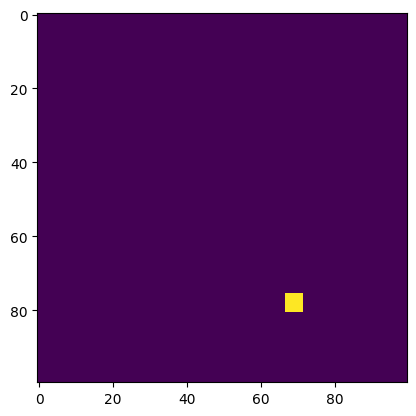

In [14]:
for _ in range(30):
    image_mask = np.zeros((100, 100))

    # randomly generate example image masks
    x = np.random.randint(0, 95)
    y = np.random.randint(0, 95)
    image_mask[x : x + 5, y : y + 5] = 1

    # add image mask to plane segmentation
    ps.add_roi(image_mask=image_mask)

# show one of the image masks
plt.imshow(image_mask)

##### Pixel masks

Alternatively, you could define ROIs using a pixel mask, which is an array of **triplets (x, y, weight)** that have a non-zero weight. All undefined pixels are assumed to be 0.

You need to be consistent within a **PlaneSegmentation** table. You can add ROIs either using image masks, pixel masks, or voxel masks.

In [15]:
ps2 = img_seg.create_plane_segmentation(
    name="PlaneSegmentation2",
    description="output from segmenting my favorite imaging plane",
    imaging_plane=imaging_plane,
    reference_images=two_p_series1,  # optional
)

for _ in range(30):
    # randomly generate example starting points for region
    x = np.random.randint(0, 95)
    y = np.random.randint(0, 95)

    # define an example 4 x 3 region of pixels of weight '1'
    pixel_mask = []
    for ix in range(x, x + 4):
        for iy in range(y, y + 3):
            pixel_mask.append((ix, iy, 1))

    # add pixel mask to plane segmentation
    ps2.add_roi(pixel_mask=pixel_mask)

In [16]:
# view the PlaneSegmentation by converting it to a DataFrame.
ps2.to_dataframe()

,pixel_mask
id,
0,"[(9, 9, 1), (9, 10, 1), (9, 11, 1), (10, 9, 1)..."
1,"[(10, 55, 1), (10, 56, 1), (10, 57, 1), (11, 5..."
2,"[(44, 74, 1), (44, 75, 1), (44, 76, 1), (45, 7..."
3,"[(2, 92, 1), (2, 93, 1), (2, 94, 1), (3, 92, 1..."
4,"[(93, 88, 1), (93, 89, 1), (93, 90, 1), (94, 8..."
5,"[(51, 63, 1), (51, 64, 1), (51, 65, 1), (52, 6..."
6,"[(85, 86, 1), (85, 87, 1), (85, 88, 1), (86, 8..."
7,"[(7, 38, 1), (7, 39, 1), (7, 40, 1), (8, 38, 1..."
8,"[(9, 70, 1), (9, 71, 1), (9, 72, 1), (10, 70, ..."


##### Voxel masks

When storing the segmentation of volumetric imaging, you can use imaging masks. Alternatively, you could define ROIs using a voxel mask, which is an array of **triplets (x, y, z, weight)** that have a non-zero weight. All undefined voxels are assumed to be 0.

In [17]:
ps3 = img_seg.create_plane_segmentation(
    name="PlaneSegmentation3",
    description="output from segmenting my favorite imaging plane",
    imaging_plane=imaging_plane,
    reference_images=two_p_series1,  # optional
)

from itertools import product

for _ in range(30):
    # randomly generate example starting points for region
    x = np.random.randint(0, 95)
    y = np.random.randint(0, 95)
    z = np.random.randint(0, 15)

    # define an example 4 x 3 x 2 voxel region of weight '0.5'
    voxel_mask = []
    for ix, iy, iz in product(range(x, x + 4), range(y, y + 3), range(z, z + 2)):
        voxel_mask.append((ix, iy, iz, 0.5))

    # add voxel mask to plane segmentation
    ps3.add_roi(voxel_mask=voxel_mask)

#### Storing Fluorescence or Df/F Measurements

Now that the regions of interest are stored, you can store fluorescence data for these ROIs. This type of data is stored using the **RoiResponseSeries** and **Fluorescence** classes.

In [18]:
Image(url="https://pynwb.readthedocs.io/en/stable/_images/RoiResponseSeries.svg", width=700)

To create a **RoiResponseSeries** object, we will need to reference a set of rows from a **PlaneSegmentation** table to indicate which ROIs correspond to which rows of your recorded data matrix. This is done using a **DynamicTableRegion**, which is a type of link that allows you to reference specific rows of a **DynamicTable**, such as a **PlaneSegmentation** table by row indices.

In [19]:
# create a **DynamicTableRegion** that references the first two ROIs of the **PlaneSegmentation** table.
rt_region = ps.create_roi_table_region(
    region=[0, 1], description="the first of two ROIs"
)

# create a RoiResponseSeries object to store fluorescence data for those two ROIs.
roi_resp_series = RoiResponseSeries(
    name="RoiResponseSeries",
    data=np.ones((50, 2)),  # 50 samples, 2 ROIs
    rois=rt_region,
    unit="lumens", #TODO: Flux= photon count per second
    rate=30.0,
)

To help data analysis and visualization tools know that this **RoiResponseSeries** object represents fluorescence data, we will store the RoiResponseSeries object inside of a **Fluorescence** object. Then add the **Fluorescence** object into the same ProcessingModule named "ophys" that we created earlier.

In [21]:
Image(url="https://pynwb.readthedocs.io/en/stable/_images/Fluorescence.svg", width=1100)

If you want to store dF/F data instead of fluorescence data, then store the **RoiResponseSeries** object in a **DfOverF** object, which works the same way as the **Fluorescence** class.

In [22]:
fl = Fluorescence(roi_response_series=roi_resp_series)
ophys_module.add(fl)

Fluorescence pynwb.ophys.Fluorescence at 0x3170345554368
Fields:
  roi_response_series: {
    RoiResponseSeries <class 'pynwb.ophys.RoiResponseSeries'>
  }

fl

#### Read, Write, Access Data

We can access the raw data by indexing **nwbfile.acquisition** with a name of the **TwoPhotonSeries**, e.g., "TwoPhotonSeries1".

In [23]:
# write
with NWBHDF5IO("ophys_tutorial.nwb", "w") as io:
    io.write(nwbfile)
# read
with NWBHDF5IO("ophys_tutorial.nwb", "r") as io:
    read_nwbfile = io.read()
    print(read_nwbfile.acquisition["TwoPhotonSeries1"])
    print(read_nwbfile.processing["ophys"])
    print(read_nwbfile.processing["ophys"]["Fluorescence"])
    print(read_nwbfile.processing["ophys"]["Fluorescence"]["RoiResponseSeries"])


TwoPhotonSeries1 pynwb.ophys.TwoPhotonSeries at 0x3170310442960
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (1000, 100, 100), type "<f8">
  description: no description
  imaging_plane: ImagingPlane pynwb.ophys.ImagingPlane at 0x3170349878624
Fields:
  conversion: 1.0
  description: CA1 imaging
  device: Microscope pynwb.device.Device at 0x3170349613456
Fields:
  description: My two-photon microscope
  manufacturer: The best microscope manufacturer

  excitation_lambda: 999.0
  imaging_rate: 30.0
  indicator: GFP
  location: V1
  optical_channel: (
    OpticalChannel <class 'pynwb.ophys.OpticalChannel'>
  )
  unit: meters

  offset: 0.0
  rate: 1.0
  resolution: -1.0
  starting_time: 0.0
  starting_time_unit: seconds
  unit: normalized amplitude

ophys pynwb.base.ProcessingModule at 0x3170346798672
Fields:
  data_interfaces: {
    Fluorescence <class 'pynwb.ophys.Fluorescence'>,
    ImageSegmentation <class 'pynwb.ophys.ImageSegmentation'>,
    

Data arrays are read passively from the file. Calling the data attribute on a **TimeSeries** such as a **RoiResponseSeries** does not read the data values, but presents an **h5py** object that can be indexed to read data. You can use the [:] operator to read the entire data array into memory. Load and print all the data values of the **RoiResponseSeries** object representing the fluorescence data.

In [ ]:
# access
with NWBHDF5IO("ophys_tutorial.nwb", "r") as io:
    read_nwbfile = io.read()

    roi_resp_series = read_nwbfile.processing["ophys"]["Fluorescence"][
        "RoiResponseSeries"
    ]

    print("section of fluorescence responses:")
    print(roi_resp_series.data[0:10, 0:3])

## Advanced I/O (empty)

# Tests

In [24]:
from datetime import datetime
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
from dateutil.tz import tzlocal

from pynwb import NWBHDF5IO, NWBFile, TimeSeries
from pynwb.image import ImageSeries
from pynwb.ophys import (
    CorrectedImageStack,
    Fluorescence,
    ImageSegmentation,
    MotionCorrection,
    OnePhotonSeries,
    OpticalChannel,
    RoiResponseSeries,
    TwoPhotonSeries,
)

F = np.load("./Test_Data/F.npy", "r")
print(F)

[[ 921.49805  853.22144  893.2502  ...  980.2765  1478.6599   918.4678 ]
 [ 906.8142   967.7758  1003.6051  ...  701.6381   730.9802   733.0222 ]
 [ 910.3513   886.177    910.9863  ...  778.31165  839.4436   853.99896]
 ...
 [ 639.00476  690.8612   739.5218  ...  792.7218   787.36536  702.4869 ]
 [ 623.0571   632.61206  645.1162  ...  599.62836  621.5422   608.7545 ]
 [ 608.484    613.6859   640.79565 ...  601.2514   595.1817   609.4018 ]]


c:\Users\mauls\miniconda3\envs\manifolds\lib\site-packages\pynwb\file.py:470: UserWarning: Date is missing timezone information. Updating to local timezone.
  args_to_set['session_start_time'] = _add_missing_timezone(session_start_time)


In [25]:
nwbfile = NWBFile(
    session_description="DON-008498_20220209",
    identifier=str(uuid4()),
    session_start_time=datetime.strptime("20220209", "%Y%m%d"),
    experimenter=[
        "Steffen Kandler",
    ],
    lab="Donatolab",
    institution="University of Basel",
    experiment_description="Running wheel",
    session_id="20220209",
)
device = nwbfile.create_device(
    name="Microscope",
    description="My two-photon microscope",
    manufacturer="The best microscope manufacturer",
)
optical_channel = OpticalChannel(
    name="OpticalChannel",
    description="an optical channel",
    emission_lambda=666.0,
)
imaging_plane = nwbfile.create_imaging_plane(
    name="ImagingPlane",
    optical_channel=optical_channel,
    imaging_rate=30.0,
    description="CA1 imaging",
    device=device,
    excitation_lambda=999.0,
    indicator="GFP",
    location="V1",
    grid_spacing=[0.01, 0.01],
    grid_spacing_unit="meters",
    origin_coords=[1.0, 2.0, 3.0],
    origin_coords_unit="meters",
)

In [ ]:
#Example getting information from suite2p data into NWB formt

import roiextractors
import numpy as np

seg_obj_cnmfe = roiextractors.CnmfeSegmentationExtractor('cnmfe_filename.mat') # cnmfe
seg_obj_extract = roiextractors.ExtractSegmentationExtractor('extract_filename.mat') # extract
seg_obj_sima = roiextractors.SimaSegmentationExtractor('sima_filename.sima') # SIMA
seg_obj_numpy = roiextractors.NumpySegmentationExtractor(
        filepath = 'path-to-file',
        masks=np.random.rand(movie_size[0],movie_size[1],no_rois),
        signal=np.random.randn(num_rois,num_frames),
        roi_idx=np.random.randint(no_rois,size=[1,no_rois]),
        no_of_channels=None,
        summary_image=None,
        channel_names=['Blue'],
) # Numpy object
seg_obj_nwb = roiextractors.NwbSegmentationExtractor(
                    filepath_of_nwb, optical_channel_name=None, # optical channel to extract and store info from
                    imaging_plane_name=None, image_series_name=None, # imaging plane to extract and store data from
                    processing_module_name=None,
                    neuron_roi_response_series_name=None, # roi_response_series name to extract and store data from
                    background_roi_response_series_name=None) # nwb object